# 🧪 YOLO11 통합 학습·제출 노트북 (Colab)

두 노트북을 하나로 합친 버전입니다. **`src/` 모듈을 그대로 재사용**하고,
**맨 위 `2. 설정` 셀 하나만 바꾸면** 각자 환경·실험에서 바로 쓸 수 있어요.

**사용법:** ① `2. 설정` 셀에서 경로·실험값만 수정 → ② 위에서 아래로 `모두 실행`.

전제: 드라이브에 `src/` 모듈들과 전처리된 YOLO 데이터셋(`images/labels/data.yaml`)이 있어야 합니다.


## 0. 설치


In [1]:
# Colab이면 실행 (로컬은 최초 1회만)
!pip -q install ultralytics wandb omegaconf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 2.7 MB/s eta 0:00:00


## 1. Google Drive 연결 · src 모듈 import


In [2]:
from pathlib import Path
import sys, os, json, shutil, gc
import torch
from omegaconf import OmegaConf
from ultralytics import YOLO

# --- Colab이면 드라이브 연결 (로컬이면 이 블록만 건너뛰세요) ---
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False
print("Colab:", IN_COLAB)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
Colab: True


## 2. ⚙️ 설정 — 여기만 바꾸면 됩니다

**경로**(각자 환경)와 **실험 세팅**(모델·학습·증강)을 한 곳에서 정합니다.
자주 바꾸는 건 `model / train / yolo_augmentation` 세 블록이에요.


In [5]:
# ============================================================
# ★★★ 설정 (경로 + 실험) — 각자 환경에 맞게 수정 ★★★
# ============================================================

# --- (A) 경로: 본인 드라이브 구조에 맞게 ---
PROJECT_ROOT     = Path("/content/drive/MyDrive/코드잇 AI 13기/AI 13기 프로젝트/프로젝트1 (3팀) /코드잇_파트2_3팀_프로젝트/pill-object-detection")
YOLO_DATASET_DIR = PROJECT_ROOT / "data" / "processed_cp_ver3"          # images/labels/data.yaml 있는 곳
RAW_DATASET_ROOT = PROJECT_ROOT / "data" / "dataset" / "cleaning_data" / "260813_improve_dataset_v2" / "sprint_ai_project1_data"

USE_LOCAL_COPY = True   # Colab: 데이터셋을 /content로 복사해 학습 (드라이브 스캔 느림 → 강력 권장)

# --- (B) config (src 모듈이 읽는 전체 설정) ---
CONFIG = {
    "project": {"seed": 42},

    "paths": {
        "project_root":    str(PROJECT_ROOT),
        "dataset_root":    str(RAW_DATASET_ROOT),
        "annotation_dir":  str(RAW_DATASET_ROOT / "train_annotations"),
        "test_image_dir":  str(RAW_DATASET_ROOT / "test_images"),
        "yolo_dataset_dir": str(YOLO_DATASET_DIR),
        "weights_path":    "",   # 학습 후 자동 채움
        "submission_path": str(PROJECT_ROOT / "outputs" / "submissions" / "EXP029-submission.csv"),
    },

    # ▼▼▼ 실험할 때 주로 바꾸는 부분 ▼▼▼
    "model": {"name": "yolo11s.pt"},          # yolo11s.pt / yolo11m.pt ...
    "train": {
        "epochs": 100, "imgsz": 960, "batch": 16,
        "workers": 2,                         # Colab에서 학습이 멈추면 0 으로
        "checkpoint_name": "yolo11s-exp",     # 결과 폴더/백업 파일 이름
    },
    "yolo_augmentation": {                    # 증강 스윕은 여기서
        "hsv_h": 0.0, "hsv_s": 0.0, "hsv_v": 0.0,
        "degrees": 0.0,                      # 알약은 방향 임의 → 회전 유효 (Kaggle 기준 90 우세)
        "translate": 0.1, "scale": 0.0, "shear": 0.0, "perspective": 0.0,
        "flipud": 0.0, "fliplr": 0.0,
        "mosaic": 0.0, "mixup": 0.0, "copy_paste": 0.0, "erasing": 0.0,
    },
    # ▲▲▲

    "augmentation": {"copy_paste": {"mode": "mix", "n_synth": 0,
                                     "max_crops_per_class": 40, "rebuild_crop_cache": False}},
    "dataset": {"image_dir_name": "train_images", "annotation_dir_name": "train_annotations",
                "label_offset": 0, "strict": False, "validate_image_size": True,
                "train_ratio": 0.8, "val_ratio": 0.1, "test_ratio": 0.1},
    "evaluation": {"imgsz": 960, "plots": True},
    "inference":  {"imgsz": 960, "conf": 0.25, "max_det": 4},   # conf 낮추면 recall↑ (0.05 등 실험)
    "wandb": {"enabled": True, "mode": "online", "project": "pill-object-detection",
              "entity": "diokim17", "run_name": None, "tags": ["yolo11s"]},
}
if CONFIG["wandb"]["run_name"] is None:
    CONFIG["wandb"]["run_name"] = CONFIG["train"]["checkpoint_name"]

cfg = OmegaConf.create(CONFIG)

# src 모듈 경로 등록 + import
SRC_ROOT = PROJECT_ROOT / "src" / "yolo"
for p in (str(PROJECT_ROOT), str(SRC_ROOT)):
    if p not in sys.path:
        sys.path.insert(0, p)

from src.yolo.runtime import set_seed, resolve_device, print_runtime_info
from src.yolo.training import train_yolo, get_best_weights
from src.yolo.evaluation import evaluate_yolo, print_evaluation
from src.yolo.submission import (list_test_images, run_inference_sanity_check,
                                 create_submission, validate_submission)
from src.yolo.yolo_mapping import build_yolo_to_category_id

print("설정 로드 완료 | 모델:", cfg.model.name, "| epochs:", cfg.train.epochs)

설정 로드 완료 | 모델: yolo11s.pt | epochs: 100


## 3. 런타임 (시드 · 디바이스)


In [6]:
set_seed(cfg.project.seed)
device = resolve_device()          # GPU 있으면 0, 없으면 "cpu"
print_runtime_info(cfg.project.seed, device)

torch: 2.11.0+cu128 | CUDA: True | device: 0 | seed: 42


## 4. (Colab 권장) 데이터셋 로컬 복사

드라이브에서 수천 개 파일을 읽으면 스캔·학습이 매우 느려요. `/content`(로컬 디스크)로 한 번 복사하면 훨씬 빠릅니다.


In [7]:
if USE_LOCAL_COPY and IN_COLAB:
    local = Path("/content/yolo_dataset")
    if not local.exists():
        print("드라이브 → 로컬 복사 중... (수분 소요, 1회)")
        shutil.copytree(cfg.paths.yolo_dataset_dir, str(local))
    cfg.paths.yolo_dataset_dir = str(local)       # 이후 로컬 사용
    print("로컬 데이터셋:", cfg.paths.yolo_dataset_dir)
else:
    print("로컬 복사 건너뜀 (드라이브 직접 사용)")

드라이브 → 로컬 복사 중... (수분 소요, 1회)
로컬 데이터셋: /content/yolo_dataset


## 5. 데이터셋 확인 · data.yaml 경로 맞춤


In [8]:
import yaml
PROCESSED_ROOT = Path(cfg.paths.yolo_dataset_dir)
data_yaml = PROCESSED_ROOT / "data.yaml"
assert (PROCESSED_ROOT / "images" / "train").is_dir(), f"images/train 없음: {PROCESSED_ROOT}"

# data.yaml의 path를 현재 위치로 덮어써서 어디서 실행하든 동작하게
ycfg = yaml.safe_load(open(data_yaml, encoding="utf-8"))
ycfg["path"] = str(PROCESSED_ROOT.resolve())
if "nc" not in ycfg and "names" in ycfg:
    ycfg["nc"] = len(ycfg["names"])
yaml.safe_dump(ycfg, open(data_yaml, "w", encoding="utf-8"), allow_unicode=True, sort_keys=False)

n_names = len(ycfg["names"])
print("클래스 수:", n_names, "| data.yaml:", data_yaml)

클래스 수: 98 | data.yaml: /content/yolo_dataset/data.yaml


## 6. 클래스 역매핑 (YOLO id → 원본 category_id)

제출은 원본 category_id가 필요해요. 저장된 매핑 json이 있으면 로드(빠름), 없으면 annotation에서 생성.


In [9]:
mapping_path = PROCESSED_ROOT / "yolo_to_category_id.json"
if mapping_path.is_file():
    with mapping_path.open(encoding="utf-8") as f:
        yolo_to_category_id = {int(k): int(v) for k, v in json.load(f).items()}
    print("저장된 매핑 사용:", len(yolo_to_category_id))
else:
    yolo_to_category_id = build_yolo_to_category_id(cfg.paths.annotation_dir)
    with mapping_path.open("w", encoding="utf-8") as f:
        json.dump(yolo_to_category_id, f, ensure_ascii=False, indent=2)
    print("매핑 생성·저장:", len(yolo_to_category_id))

assert len(yolo_to_category_id) == n_names, "매핑 수와 data.yaml 클래스 수가 다릅니다!"
print("예시:", list(yolo_to_category_id.items())[:3])

저장된 매핑 사용: 98
예시: [(0, 1900), (1, 2483), (2, 3351)]


## 7. 학습 (W&B 로깅 포함)


In [10]:
model, results = train_yolo(cfg, data_yaml=data_yaml, device=device)
best_weights = get_best_weights(results)
cfg.paths.weights_path = str(best_weights)
print("best.pt:", best_weights)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: wonyounglee226 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=yolo11s-exp, nbs=64, nms=False,

wandb: WARNING Tried to log to step 100 that is less than the current step 102. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


lr/pg0,▃███▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁
lr/pg1,▃████▇▇▇▇▇▇▇▇▇▇▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁
lr/pg2,▆███▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁
metrics/mAP50(B),▁▇▇▇█████▇███████████▇▇▇██▇███▇▇▇▇▇▇▇▇▇█
metrics/mAP50-95(B),▁▄▅▅▆▇▆▆▇▇▇▆▄██▇▆▅▇▇▆▆▆▅▅▆▅▅▄▅▅▅▄▄▄▄▄▄▅▅
metrics/precision(B),▄▅▆▂▁▆▆▇▇▅▇▇▆█▇▇▇▇▇▆▃▇▇▇▇▄▇▇▇▇▄█▄▄▄▄█▄▄█
metrics/recall(B),▂▁▅▆▇▇▆▆▆▇▆█▆▆▆▇▆▆▆▆▅▇▆▅▅▆▅▇█▇▆▆▆▇▆▇▆▆▆█
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...


best.pt: /content/drive/.shortcut-targets-by-id/1ynTDOjqYBMr60qiTLLeOoMxWD4B_hAjF/코드잇_파트2_3팀_프로젝트/pill-object-detection/outputs/yolo/yolo11s-exp/weights/best.pt


── train_batch0.jpg (증강 적용된 학습 배치) ──


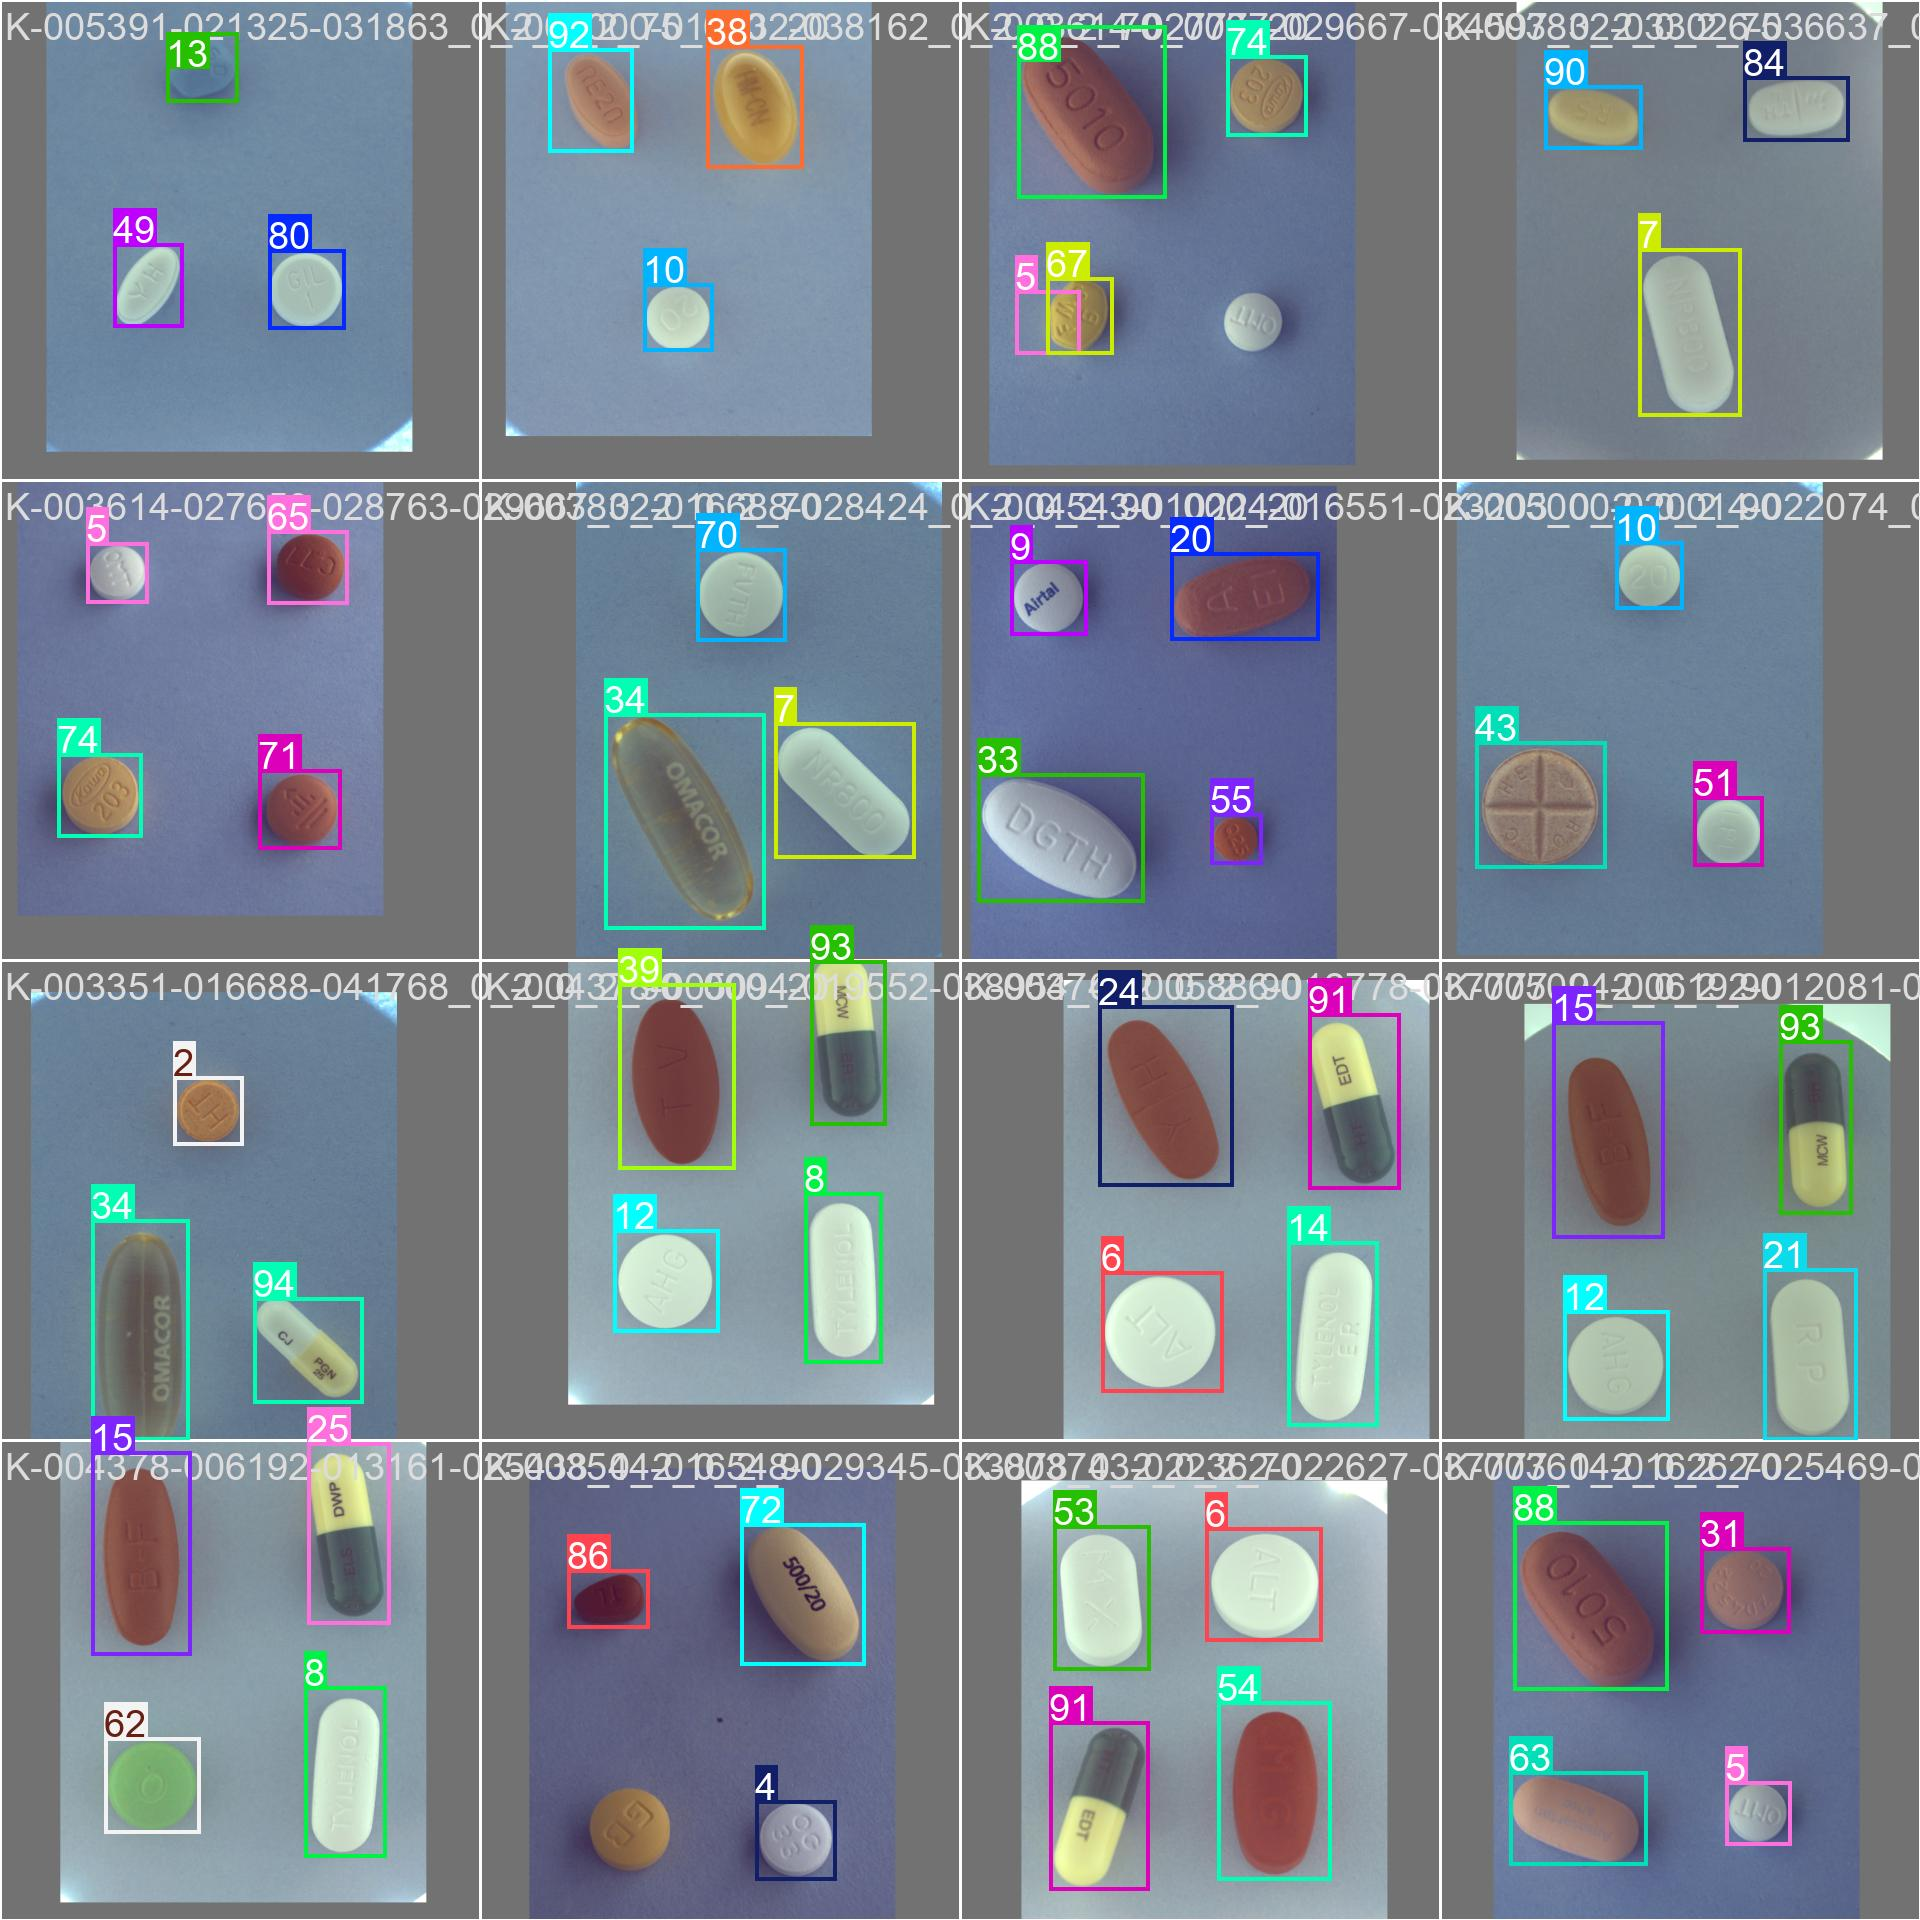

── train_batch1.jpg (증강 적용된 학습 배치) ──


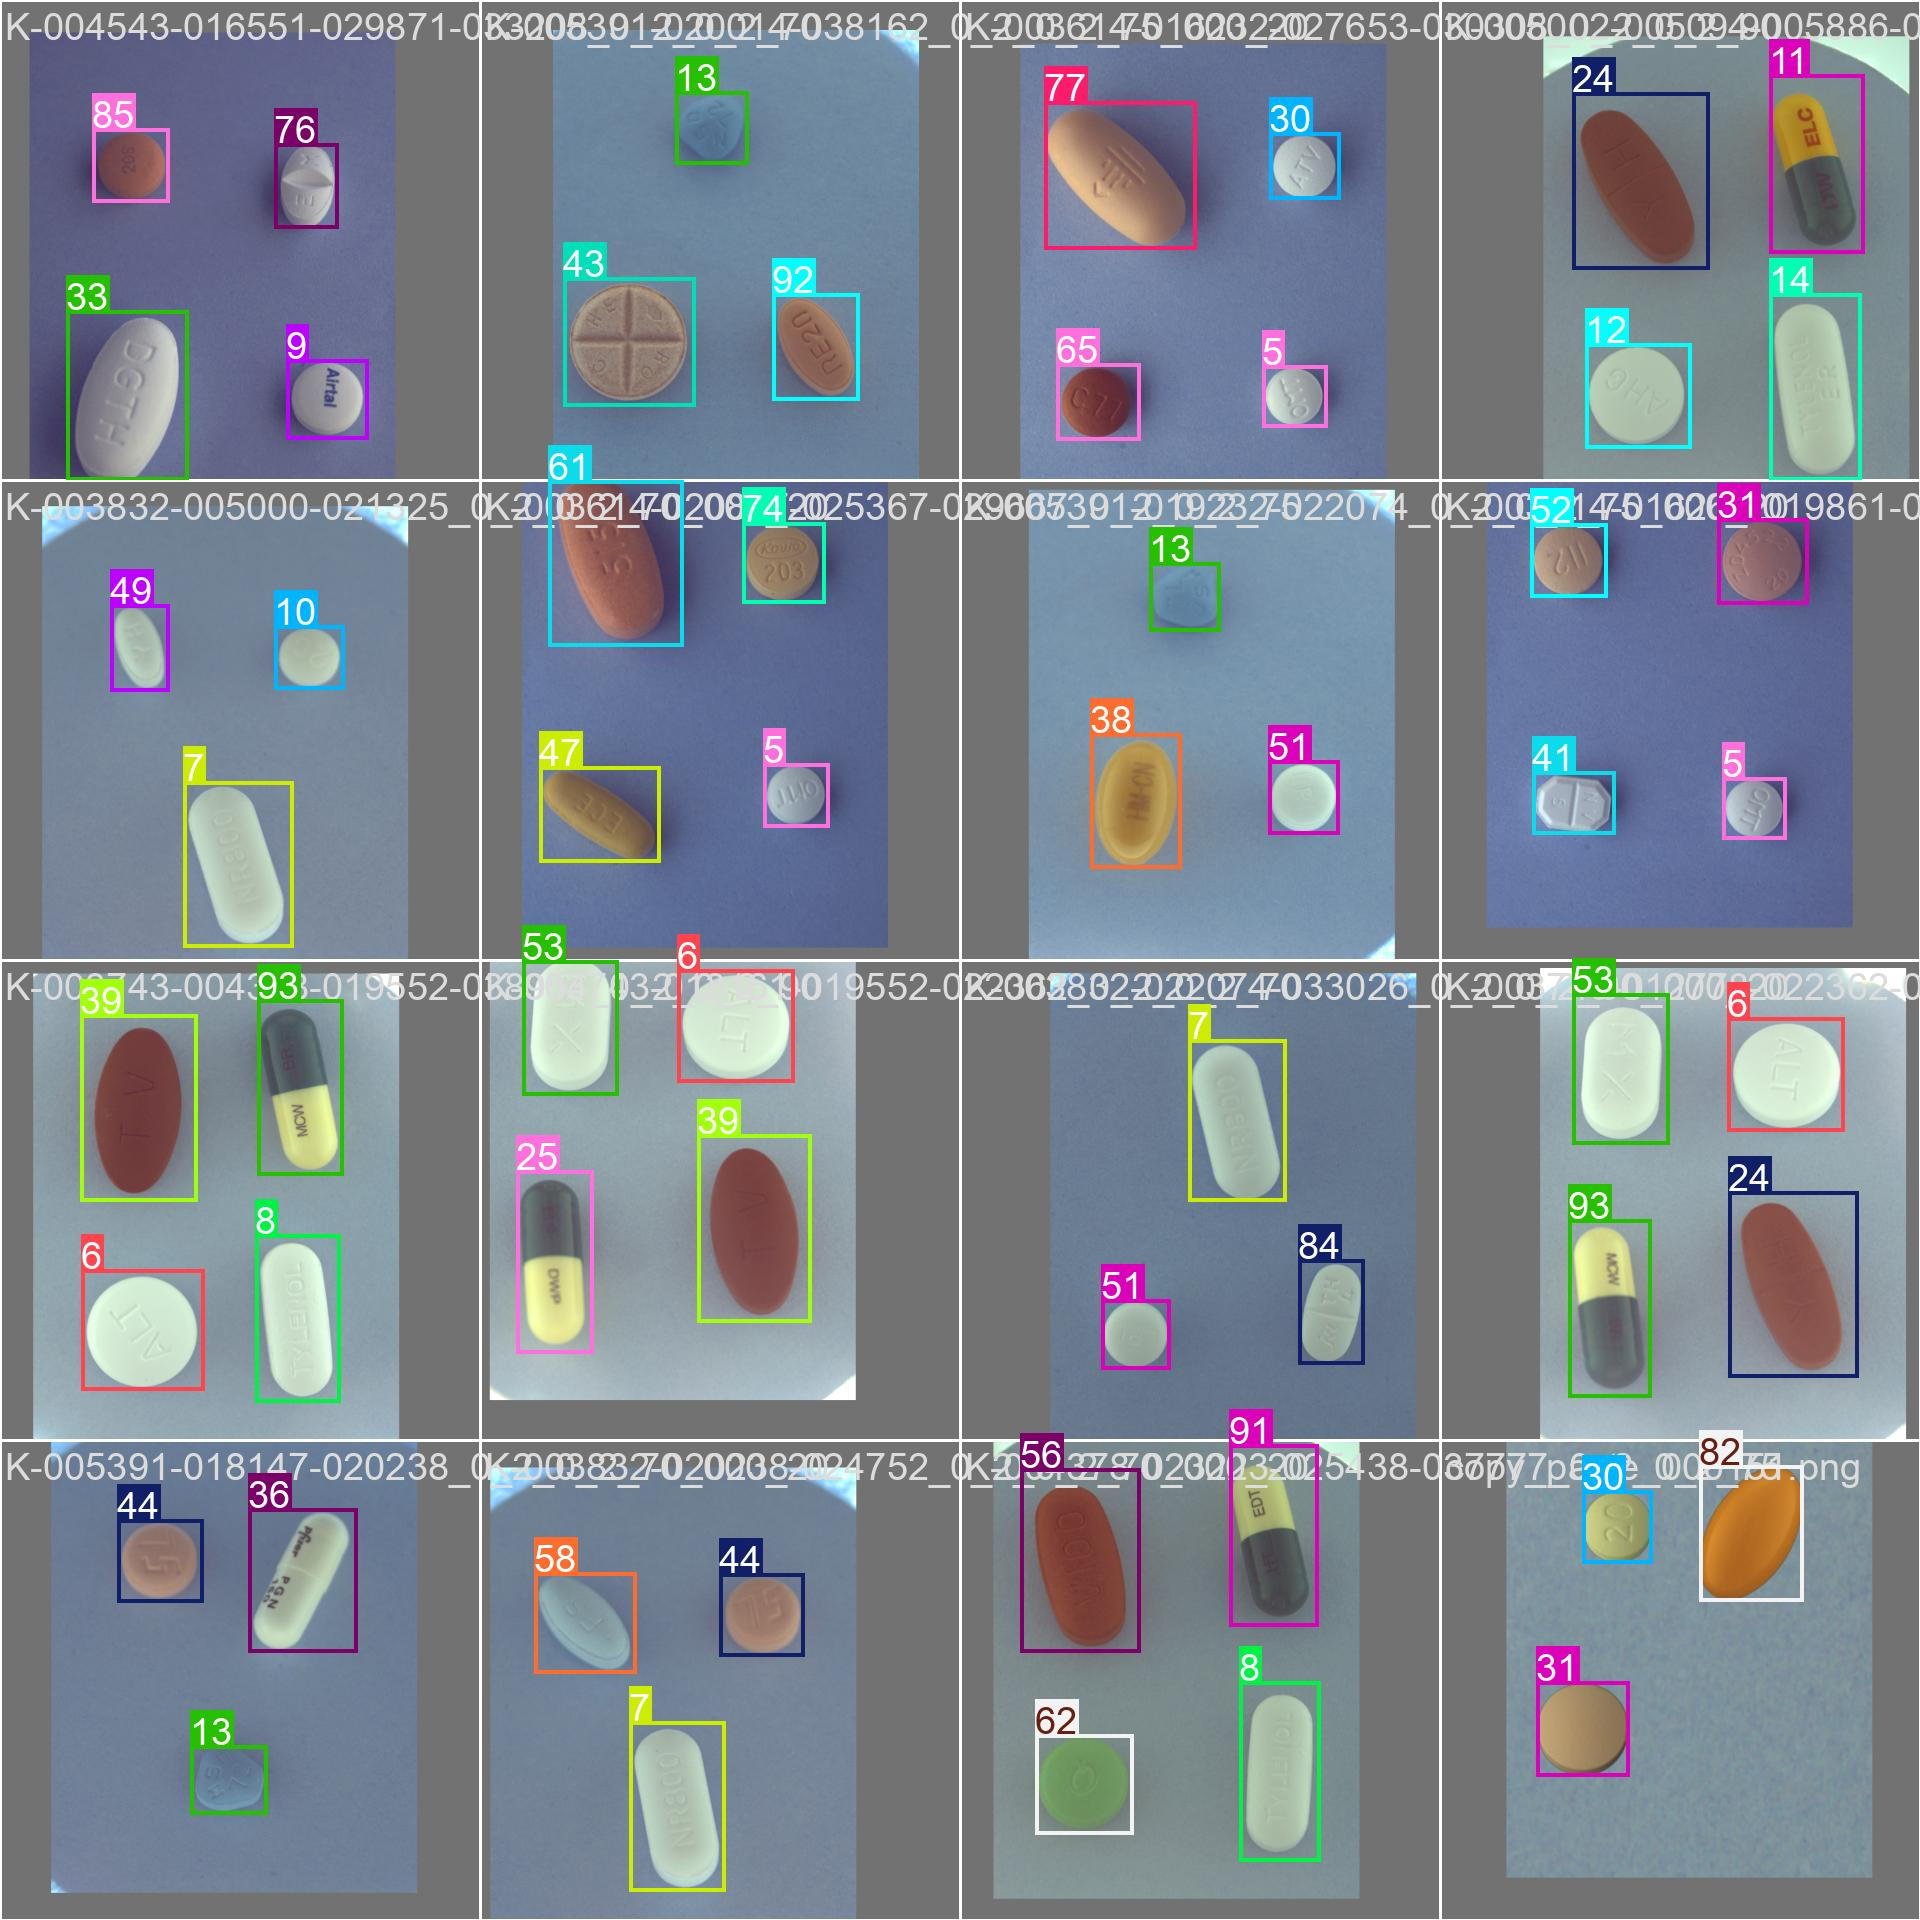

── train_batch2.jpg (증강 적용된 학습 배치) ──


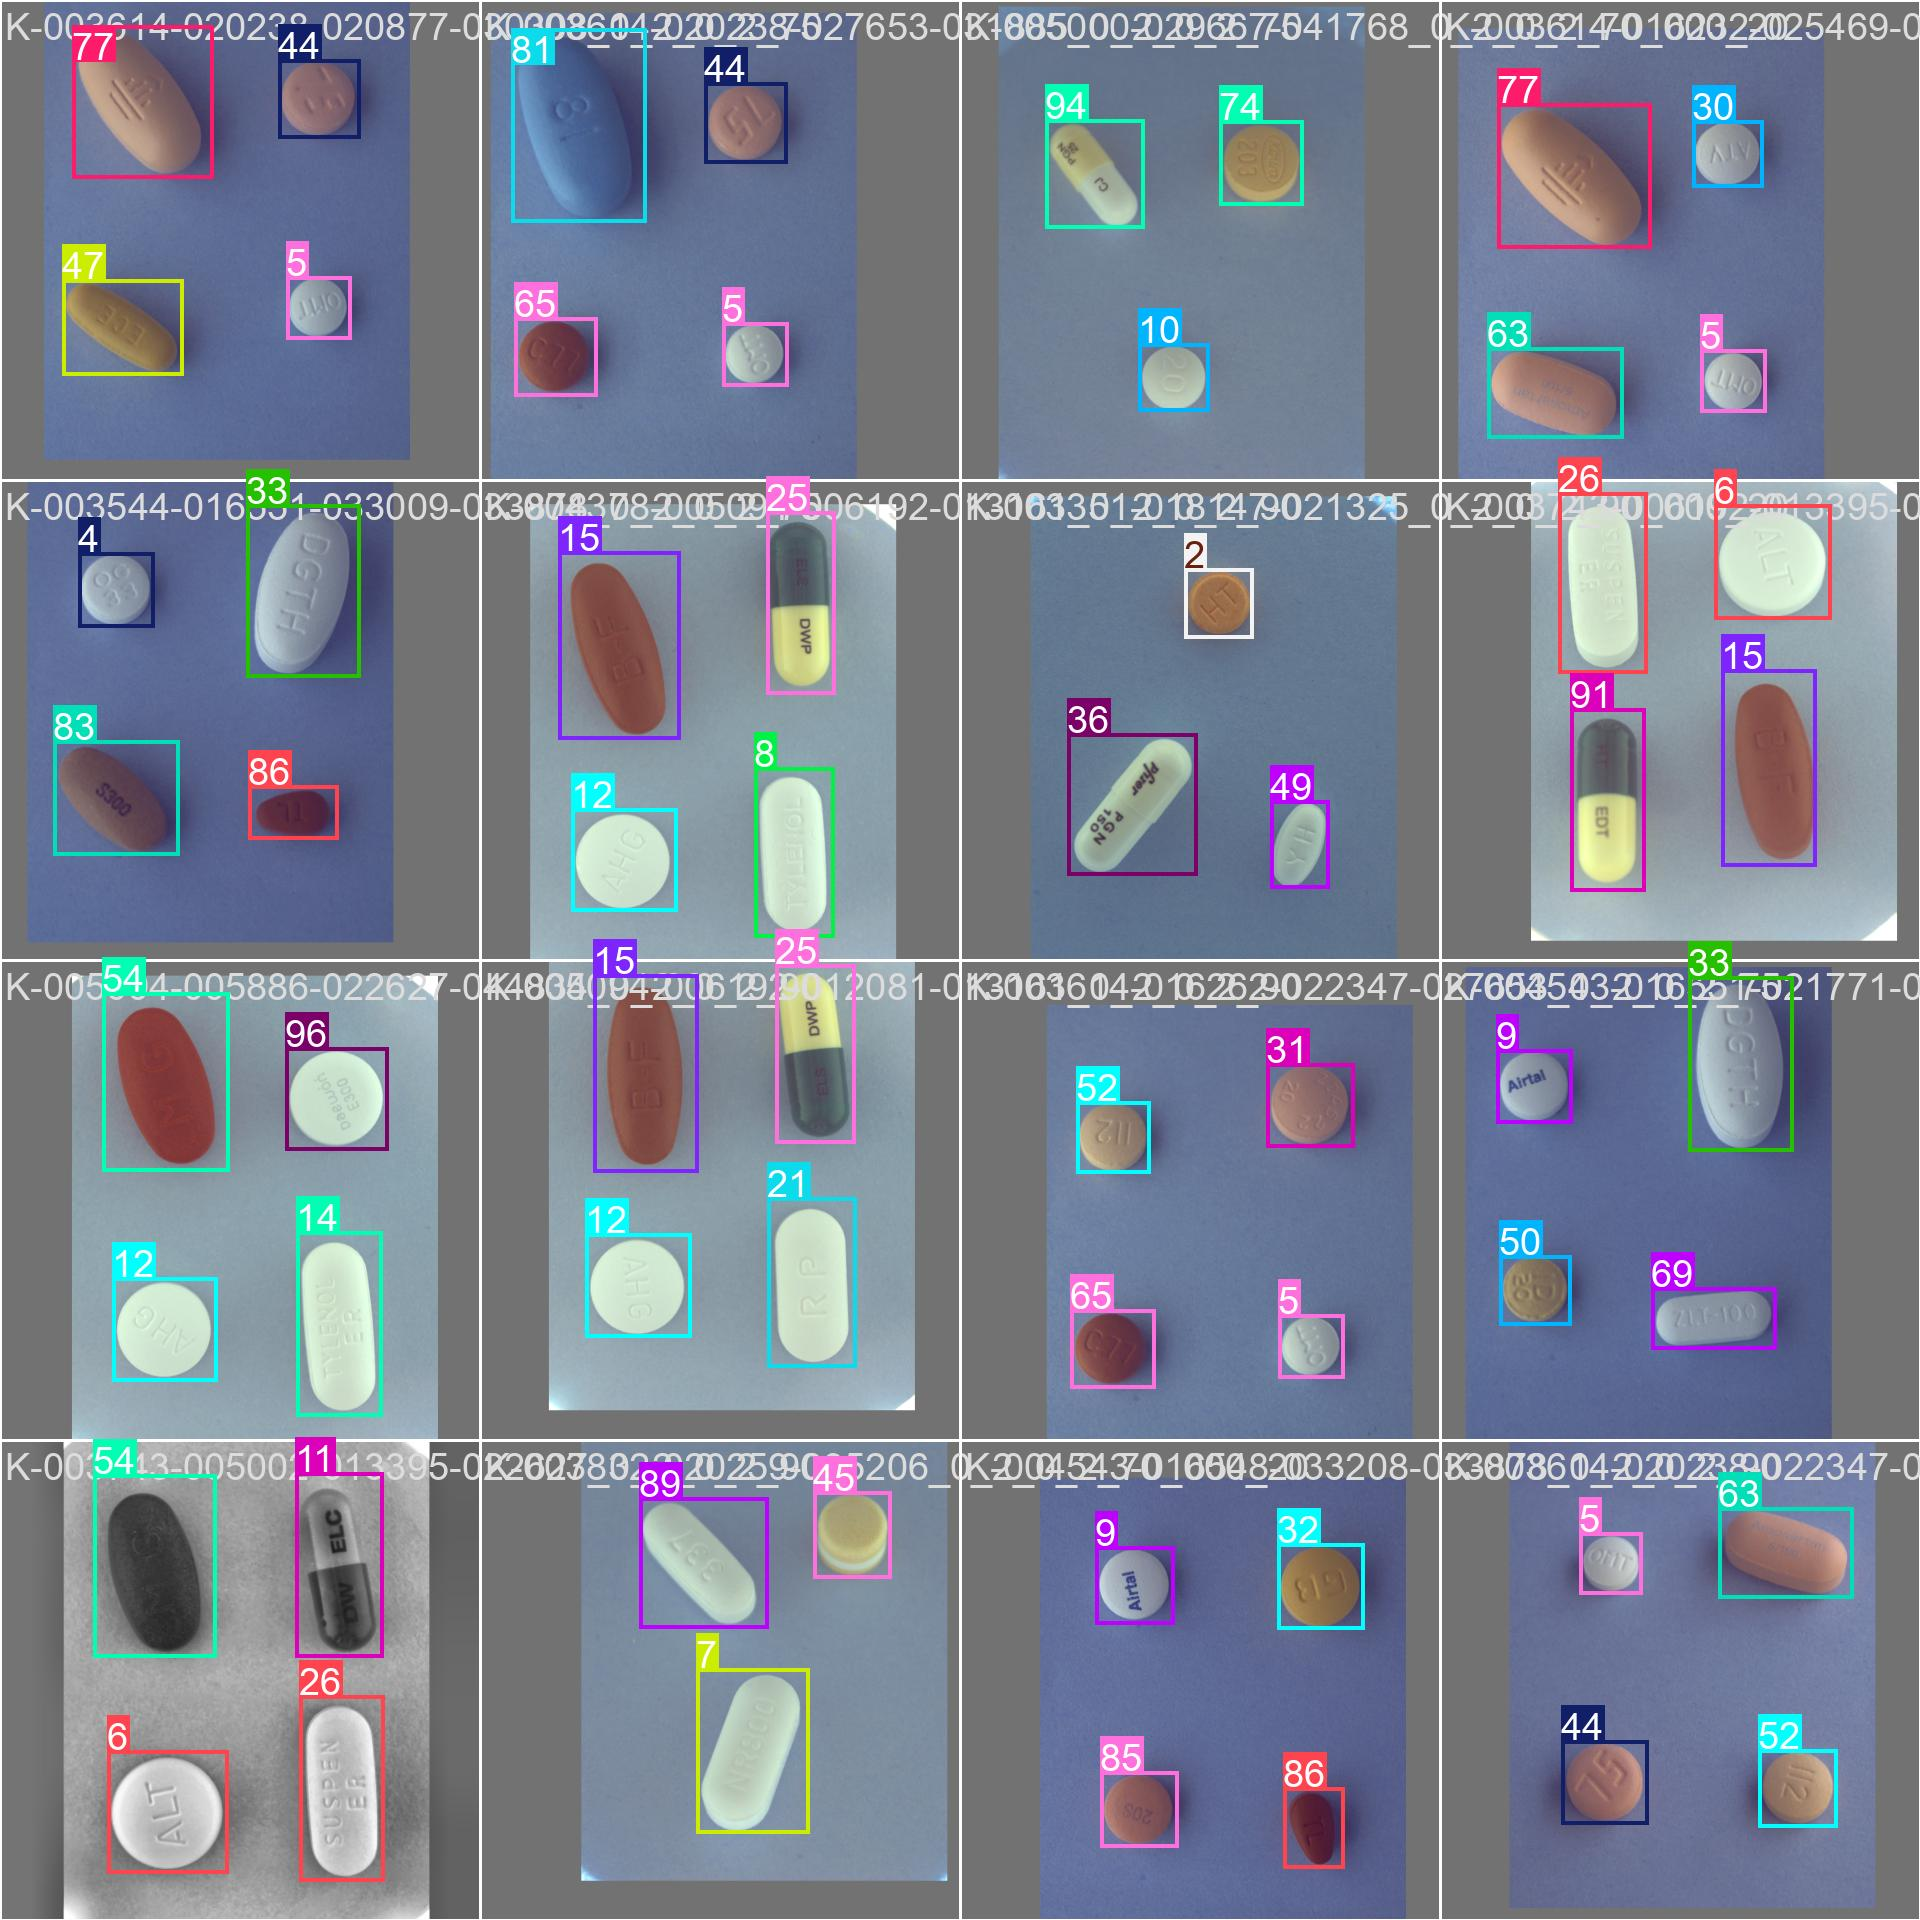

In [11]:
# ============================================================
# 증강 후 데이터 상태 시각화 (Ultralytics가 학습 중 저장한 실제 증강 배치)
# ============================================================
from IPython.display import Image as IPyImage, display
from pathlib import Path

run_dir = Path(results.save_dir)   # 학습 결과 폴더
shown = False
for name in ["train_batch0.jpg", "train_batch1.jpg", "train_batch2.jpg"]:
    p = run_dir / name
    if p.exists():
        print(f"── {name} (증강 적용된 학습 배치) ──")
        display(IPyImage(filename=str(p)))
        shown = True
if not shown:
    print("train_batch*.jpg 가 아직 없어요. 학습을 최소 1 epoch 이상 돌렸는지 확인하세요.")

## 8. best.pt 백업 (로컬 → Drive)


In [12]:
# 로컬(/content)에 저장된 결과는 런타임 종료 시 사라지므로 Drive로 백업
dst = PROJECT_ROOT / "outputs" / "yolo" / f"{cfg.train.checkpoint_name}_best.pt"
dst.parent.mkdir(parents=True, exist_ok=True)
shutil.copy(str(best_weights), str(dst))
print("Drive 백업:", dst)

Drive 백업: /content/drive/MyDrive/코드잇 AI 13기/AI 13기 프로젝트/프로젝트1 (3팀) /코드잇_파트2_3팀_프로젝트/pill-object-detection/outputs/yolo/yolo11s-exp_best.pt


## 9. 검증 (mAP) — val · test(eval)


In [13]:
for split in ["val", "test"]:
    res = evaluate_yolo(best_weights, data_yaml=data_yaml, split=split,
                        imgsz=cfg.evaluation.imgsz, device=device, plots=cfg.evaluation.plots)
    print_evaluation(res, prefix=split)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,450,726 parameters, 0 gradients, 21.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3981.0±621.7 MB/s, size: 1763.7 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 326 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 326/326 113.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 1.3it/s 16.7s
                   all        326       1221      0.971      0.967      0.971      0.965
            보령부스파정 5mg          3          3          1      0.942      0.995      0.995
           뮤테란캡슐 100mg          6          6          1      0.521      0.995      0.949
           일양하이트린정 2mg         14         14      0.991          1      0.995      0.995
    기넥신에프정(은행엽엑스)(수출용)          9          9      0.985          1      0.995      0.995
     무코스타정(레바미피드)(비매품)         12    

## 10. Kaggle 제출 파일 생성 · 검증


In [14]:
test_dir = Path(cfg.paths.test_image_dir)

# 제출 전 1장 sanity 체크
run_inference_sanity_check(best_weights, test_image_dir=test_dir,
                           yolo_to_category_id=yolo_to_category_id,
                           imgsz=cfg.inference.imgsz, conf=cfg.inference.conf,
                           max_det=cfg.inference.max_det, device=device)

submission_path = Path(cfg.paths.submission_path)
submission_path = create_submission(best_weights, test_image_dir=test_dir,
                                    submission_path=submission_path,
                                    yolo_to_category_id=yolo_to_category_id,
                                    imgsz=cfg.inference.imgsz, conf=cfg.inference.conf,
                                    max_det=cfg.inference.max_det, device=device,
                                    clear_cache_every=100)

df = validate_submission(submission_path,
                         valid_category_ids=yolo_to_category_id.values(),
                         expected_image_count=len(list_test_images(test_dir)))
print("제출:", submission_path, "| 행:", len(df))
display(df.head())

테스트 이미지: 842 | 첫 장 크기: (976, 1280)
첫 이미지: 1.png | 검출 수: 4 | category_id 예: [1900, 27926, 24850, 16551]
1/842 처리 중...
100/842 처리 중...
200/842 처리 중...
300/842 처리 중...
400/842 처리 중...
500/842 처리 중...
600/842 처리 중...
700/842 처리 중...
800/842 처리 중...
Submission 작성 완료: /content/drive/MyDrive/코드잇 AI 13기/AI 13기 프로젝트/프로젝트1 (3팀) /코드잇_파트2_3팀_프로젝트/pill-object-detection/outputs/submissions/EXP029-submission.csv
행 수: 3211
Submission 검증 완료
shape: (3211, 8)
category_id 범위: 1900 ~ 44199
score 범위: 0.2718 ~ 0.9984
제출: /content/drive/MyDrive/코드잇 AI 13기/AI 13기 프로젝트/프로젝트1 (3팀) /코드잇_파트2_3팀_프로젝트/pill-object-detection/outputs/submissions/EXP029-submission.csv | 행: 3211


,annotation_id,image_id,category_id,bbox_x,bbox_y,bbox_w,bbox_h,score
0,1,1,1900,157,251,202,124,0.9801
1,2,1,27926,602,672,250,483,0.9793
2,3,1,24850,173,744,181,287,0.9637
3,4,1,16551,555,74,402,402,0.7886
4,5,3,1900,140,242,198,127,0.9826


## 11. (선택) 예측 시각화

submission.csv의 예측 박스를 test 이미지 위에 그려 확인합니다(페이지별 png 저장).


In [15]:
import math, matplotlib.pyplot as plt, matplotlib.font_manager as fm
from matplotlib.patches import Rectangle
from PIL import Image
import pandas as pd

!apt-get -qq install -y fonts-nanum >/dev/null 2>&1
for fp in fm.findSystemFonts():
    if "Nanum" in fp: fm.fontManager.addfont(fp)
plt.rcParams["font.family"] = "NanumGothic"; plt.rcParams["axes.unicode_minus"] = False

cat2name = {v: k for k, v in zip(ycfg["names"].values(), yolo_to_category_id.values())} \
           if isinstance(ycfg["names"], dict) else {}
sub = pd.read_csv(submission_path)
ids = sorted(sub["image_id"].unique())[:20]          # 앞 20장만 미리보기
out_dir = Path("/content/pred_vis"); out_dir.mkdir(exist_ok=True)

for page in range(math.ceil(len(ids)/10)):
    chunk = ids[page*10:(page+1)*10]
    fig, axes = plt.subplots(2, 5, figsize=(25, 11)); axes = axes.ravel()
    for k, iid in enumerate(chunk):
        ax = axes[k]
        try: ax.imshow(Image.open(test_dir / f"{iid}.png").convert("RGB"))
        except Exception: ax.axis("off"); continue
        for j, (_, r) in enumerate(sub[sub.image_id == iid].iterrows()):
            ax.add_patch(Rectangle((r.bbox_x, r.bbox_y), r.bbox_w, r.bbox_h,
                                   fill=False, edgecolor=plt.cm.tab10(j % 10), lw=2))
            ax.text(r.bbox_x, r.bbox_y - 5, f"{int(r.category_id)} {r.score:.2f}", fontsize=8, color="red")
        ax.set_title(f"[{iid}] 검출 {len(sub[sub.image_id==iid])}"); ax.axis("off")
    for k in range(len(chunk), 10): axes[k].axis("off")
    fig.savefig(out_dir / f"pred_{page+1:02d}.png", dpi=120, bbox_inches="tight"); plt.close(fig)
print("시각화 저장:", out_dir)

시각화 저장: /content/pred_vis
